# 25 — The necessity test (E19): adequacy-forced cells (T1), leave-EFG-out agreement (T2), the T3 gate (zero solves)

**Question:** are high-F selections driven by the EFG block CAUSALLY, not just by overlap (E13 / T-D1 were overlap-based;
the leave-block-out anchors (E17 T3) were anchor-only)? **T1 — the adequacy-forced set:** for a retained class whose
capture is 1.0 in EVERY near-optimal member of a formulation, every unlocked cell of that class has f = 1 by arithmetic
— it is in the tier because it is the only X on the extent, not because it beat alternatives. Identified exactly from
the member rasters (guarded band = the package basis; unguarded beside it). Ensemble-forced = forced in every design
formulation. **T2:** core cells absent from every no-EFG anchor (18b) are EFG-necessary by counterfactual; agreement with
T1 is reported (necessary − forced = cells EFG pulls in without forcing — informative). **T3 gate (pre-stated):** the
no-EFG ensemble runs only if the ensemble-forced share of the core exceeds 50% ("predominantly forced").
Pre-stated expectation on the curated block: a real but MINORITY forced share. Runs on `VERSION = "v3"` outputs only
(after 12, 18 and 18b T2); 19 then adds the % adequacy-forced column and the adequacy-pin caption. Kernel `y2y-geo`.

In [5]:
# ---- bootstrap: members, EFG classes, per-formulation forced sets ------------------------------------------
import importlib, json, pathlib, sys
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc
for _m in (config, lc, ec, dc):
    importlib.reload(_m)
VP = dc.VP
assert VP.version != "v1", "the necessity test (E19) runs on the curated-block re-solve only (study plan v0.17.2)"
assert config.EFG_SUBDIR == VP.efg_subdir
G = dc.grid(); RUNS, REC = dc.RUNS, dc.SPEC_REC; REC.mkdir(exist_ok=True)
FIG = ROOT / "analyses" / "y2y" / "figures" / VP.version; FIG.mkdir(exist_ok=True, parents=True)
MAN = dc.package_manifest(pd.read_csv(dc.MANIFEST)); FORMS = list(MAN.formulation_id); THR = dc.FREQ_THR
code_of = lambda p: p.stem.split(".web")[0]
EFG = []
for p in lc.efg_paths():
    pres = np.nan_to_num(lc._read(p)[G.pu], nan=0.0) > 0
    EFG.append(dict(feature=p.stem, code=code_of(p), present=pres, unlocked=pres & G.disc, cells=int(pres.sum()), n_unlocked=int((pres & G.disc).sum())))
print(f"VERSION {VP.version}: {len(FORMS)} design formulations | {len(EFG)} EFG features")
F_G, FORCED = {}, {}                        # per formulation: guarded f; forced masks per band
rows = []
for fid in FORMS:
    cd = RUNS / fid
    A = ec.read_selections(cd / "anchor.tif", G.pu)[0]
    bands = {"guarded": np.vstack([A[None, :], ec.read_selections(cd / "mga_guard_g05.tif", G.pu)]),
             "unguarded": np.vstack([A[None, :], ec.read_selections(cd / "mga_g05.tif", G.pu)])}
    F_G[fid] = bands["guarded"].mean(0).astype(np.float32)
    FORCED[fid] = {}
    for band, S in bands.items():
        fm = np.zeros(G.n_pu, bool)
        for e in EFG:
            if e["n_unlocked"] == 0:            # class entirely inside PAs: nothing to force
                forced, mincap = False, np.nan
            else:
                sel = S[:, e["unlocked"]]
                mincap = float(sel.mean(1).min())          # least-selecting member's share of the class's unlocked cells
                forced = bool(sel.all())
            if forced:
                fm |= e["unlocked"]
            rows.append(dict(formulation=fid, band=band, code=e["code"], feature=e["feature"], n_unlocked=e["n_unlocked"], min_capture_unlocked=mincap, forced=forced))
        FORCED[fid][band] = fm
    del bands
    print(f"{fid:<22} forced classes guarded {sum(r['forced'] for r in rows if r['formulation'] == fid and r['band'] == 'guarded'):2d} / "
          f"unguarded {sum(r['forced'] for r in rows if r['formulation'] == fid and r['band'] == 'unguarded'):2d} | "
          f"forced cells (guarded) {int(FORCED[fid]['guarded'].sum()):,}")
PER = pd.DataFrame(rows)


VERSION v3.1: 12 design formulations | 20 EFG features
s0_ssp585_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s1_ssp585_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s2_ssp585_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s3_ssp585_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s4_ssp585_theta3       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s5_ssp585_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s0_ssp245_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s1_ssp245_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s2_ssp245_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s3_ssp245_theta5       forced classes guarded  0 / unguarded  0 | forced cells (guarded) 0
s4_ssp245_theta3       forced class

In [6]:
# ---- T1 products: ensemble-forced set, the core partition, the T3 gate ------------------------------------------
F12 = np.mean([F_G[f] for f in FORMS], 0); core = (F12 >= THR) & G.disc
OUT = {}
for band in ("guarded", "unguarded"):
    stack = np.stack([FORCED[f][band] for f in FORMS])
    OUT[band] = dict(any=stack.any(0), all=stack.all(0), n=stack.sum(0))
any_g, all_g = OUT["guarded"]["any"], OUT["guarded"]["all"]
CLS = PER[PER.band == "guarded"].groupby(["code", "feature", "n_unlocked"]).agg(n_forms_forced_guarded=("forced", "sum"), min_capture_guarded=("min_capture_unlocked", "min")).reset_index()
CLS = CLS.merge(PER[PER.band == "unguarded"].groupby("code").agg(n_forms_forced_unguarded=("forced", "sum")).reset_index(), on="code")
CLS["pct_of_unlocked_class_in_core"] = [100 * float((e["unlocked"] & core).sum() / max(e["n_unlocked"], 1)) for e in sorted(EFG, key=lambda e: e["code"]) for _ in [0] if True] if False else [
    100 * float((next(e for e in EFG if e["code"] == c)["unlocked"] & core).sum() / max(next(e for e in EFG if e["code"] == c)["n_unlocked"], 1)) for c in CLS.code]
CLS = CLS.sort_values("n_unlocked").reset_index(drop=True)
CLS.to_csv(REC / "E19_forced.csv", index=False)
print("per class (guarded band): formulations in which the class is adequacy-forced (capture 1.0 in every member):")
print(CLS.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
# forced-class attribution raster: the smallest-footprint class forcing the cell (in >= 1 formulation, guarded band)
attr = np.zeros(G.n_pu, np.uint8); names = {}
for k, e in enumerate(sorted(EFG, key=lambda e: -e["cells"]), 1):       # largest first so the smallest wins the overwrite
    forced_in = PER[(PER.band == "guarded") & (PER.code == e["code"]) & PER.forced].formulation.tolist()
    if forced_in:
        attr[e["unlocked"]] = k; names[k] = e["code"]
attr[~any_g] = 0
code_r = np.where(all_g, 2, np.where(any_g, 1, 0)).astype(np.uint8)
dc.write_tif(G, code_r, RUNS / "e19_forced.tif", dtype="uint8", nodata=255)
dc.write_tif(G, attr, RUNS / "e19_forced_class.tif", dtype="uint8", nodata=255)
(REC / "E19_forced_classes.json").write_text(json.dumps({str(k): v for k, v in names.items()}, indent=1))
share_all = float((core & all_g).sum() / max(core.sum(), 1)); share_any = float((core & any_g).sum() / max(core.sum(), 1))
print(f"\nadequacy-forced land (guarded band): in >= 1 formulation {int(any_g.sum()):,} km2 | in ALL {len(FORMS)} formulations {int(all_g.sum()):,} km2")
print(f"core ({int(core.sum()):,} km2, F >= {THR} on the {len(FORMS)} design formulations): forced in all formulations {100*share_all:.1f}% | forced in >= 1: {100*share_any:.1f}%")
print(f"unguarded band, for the paper: forced in all {int(OUT['unguarded']['all'].sum()):,} km2 | core share {100*float((core & OUT['unguarded']['all']).sum()/max(core.sum(),1)):.1f}%")
gate = dict(version=VP.version, rule="T3 (the no-EFG ensemble) runs iff the ensemble-forced share of the core > 0.50",
            forced_share_core_all=share_all, forced_share_core_any=share_any, core_km2=int(core.sum()), forced_all_km2=int(all_g.sum()),
            forced_any_km2=int(any_g.sum()), n_classes_forced_all=int((CLS.n_forms_forced_guarded == len(FORMS)).sum()),
            t3_triggered=bool(share_all > 0.50))
(REC / "e19_gate.json").write_text(json.dumps(gate, indent=1))
print(f"\nT3 GATE: {'TRIGGERED' if gate['t3_triggered'] else 'NOT triggered'} (forced share of the core {100*share_all:.1f}% vs 50%) -> spec/{VP.version}/e19_gate.json")


per class (guarded band): formulations in which the class is adequacy-forced (capture 1.0 in every member):
       code                   feature  n_unlocked  n_forms_forced_guarded  min_capture_guarded  n_forms_forced_unguarded  pct_of_unlocked_class_in_core
       T6.1         T6.1.web.map_v1.0        1402                       0                0.136                         0                         18.973
       F1.1         F1.1.web.mix_v2.0        1419                       0                0.000                         0                          0.000
       T5.4         T5.4.web.mix_v1.0        2234                       0                0.013                         0                          0.000
       F2.1         F2.1.web.alt_v4.0        4868                       0                0.005                         0                          0.431
       F1.6         F1.6.web.mix_v1.0        6632                       0                0.082                         0            

In [7]:
# ---- T2: leave-EFG-out anchors (24) vs the forced set -----------------------------------------------------------
T2 = RUNS / "e19_t2"
have = [f for f in FORMS if (T2 / f / "run" / "portfolio.tif").exists()]
if len(have) < len(FORMS):
    print(f"T2 anchors present for {len(have)}/{len(FORMS)} formulations -- run 18b_e19_solves (T2 cell) then re-run this cell")
else:
    NOEFG = {f: ec.read_selections(T2 / f / "run" / "portfolio.tif", G.pu)[0] for f in FORMS}
    WITH = {f: ec.read_selections(RUNS / f / "anchor.tif", G.pu)[0] for f in FORMS}
    ever = np.zeros(G.n_pu, bool)
    for f in FORMS:
        ever |= NOEFG[f]
    necessary = core & ~ever                       # core cells no EFG-free anchor ever selects
    lat, _ = dc.latlon(G)
    rows = []
    for f in FORMS:
        a, b = WITH[f] & G.disc, NOEFG[f] & G.disc
        pv = json.loads((T2 / f / "run" / "run_summary.json").read_text()).get("solver_provenance", {})
        rows.append(dict(formulation=f, jaccard_with_vs_without_EFG=dc.jaccard(a, b), lat_with=float(lat[a].mean()), lat_without=float(lat[b].mean()),
                         core_cells_dropped_without_EFG=int((core & a & ~b).sum()), t2_status=pv.get("status"), t2_gap=float(pv.get("gap", float("nan")))))
    T2T = pd.DataFrame(rows); T2T.to_csv(REC / "E19_t2_anchors.csv", index=False)
    print(T2T.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    inter, nec_only, forced_only = int((necessary & all_g).sum()), int((necessary & ~all_g).sum()), int((all_g & core & ~necessary).sum())
    print(f"\nEFG-necessary core cells (absent from every no-EFG anchor): {int(necessary.sum()):,} km2 = {100*necessary.sum()/max(core.sum(),1):.1f}% of the core")
    print(f"agreement with T1: necessary AND forced-in-all {inter:,} | necessary but NOT forced (pulled in without forcing) {nec_only:,} | forced but not necessary {forced_only:,}")
    gate.update(t2_necessary_km2=int(necessary.sum()), t2_necessary_share_core=float(necessary.sum() / max(core.sum(), 1)),
                t2_necessary_and_forced=inter, t2_necessary_not_forced=nec_only, t2_forced_not_necessary=forced_only,
                t2_mean_lat_shift=float(T2T.lat_without.mean() - T2T.lat_with.mean()))
    (REC / "e19_gate.json").write_text(json.dumps(gate, indent=1))
    dc.write_tif(G, necessary.astype(np.uint8), RUNS / "e19_necessary.tif", dtype="uint8", nodata=255)


     formulation  jaccard_with_vs_without_EFG  lat_with  lat_without  core_cells_dropped_without_EFG t2_status  t2_gap
s0_ssp585_theta5                        0.919    52.926       53.070                              34   OPTIMAL   0.000
s1_ssp585_theta5                        0.924    52.570       52.676                               0   OPTIMAL   0.000
s2_ssp585_theta5                        0.946    56.359       56.544                              26   OPTIMAL   0.000
s3_ssp585_theta5                        0.930    50.348       50.406                              73   OPTIMAL   0.000
s4_ssp585_theta3                        0.930    55.706       55.919                              74   OPTIMAL   0.000
s5_ssp585_theta5                        0.909    53.529       53.746                              48   OPTIMAL   0.000
s0_ssp245_theta5                        0.930    51.980       52.068                              18   OPTIMAL   0.000
s1_ssp245_theta5                        0.942   

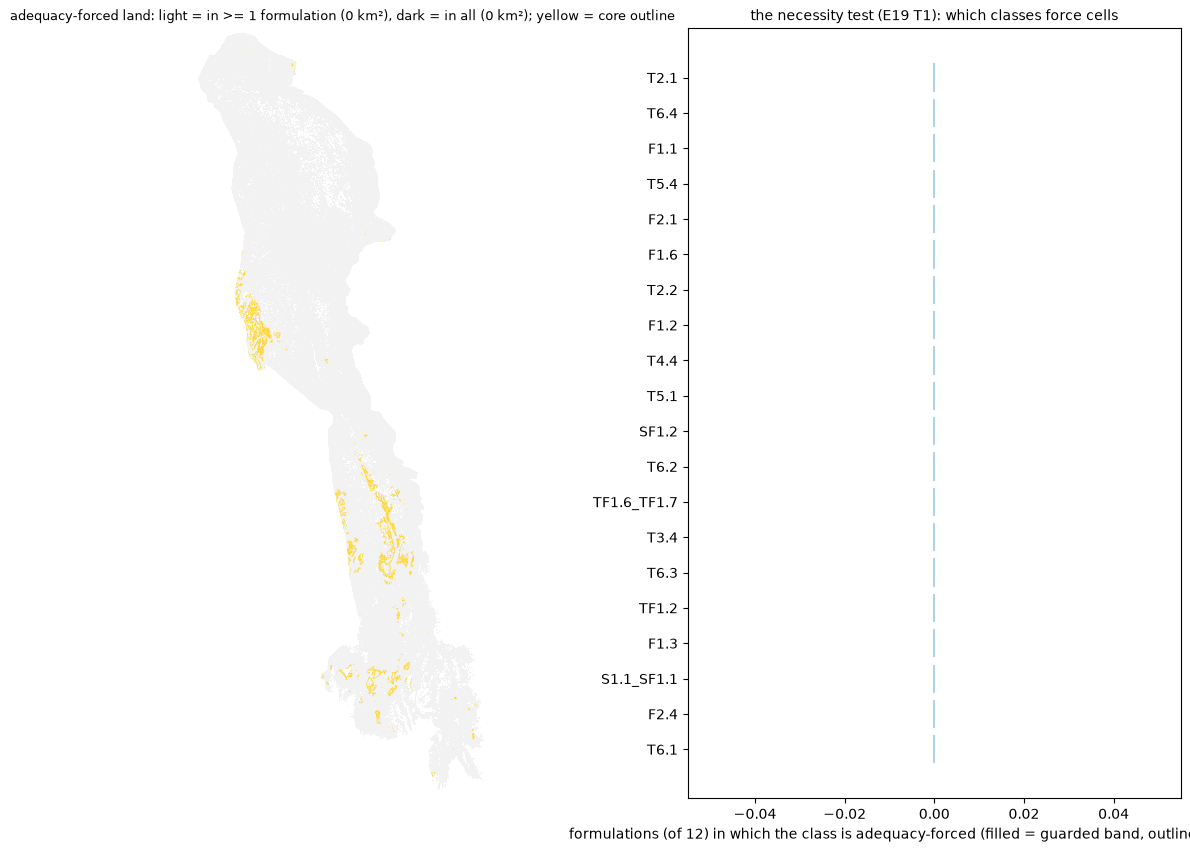

In [8]:
# ---- figures: where the forced land is, and the per-class ledger -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
cmap = plt.matplotlib.colors.ListedColormap(["#f2f2f2", "#9ecae1", "#08306b"])
ax = axes[0]
ax.imshow(dc.to_grid(G, code_r.astype(np.float32)), cmap=cmap, vmin=-0.5, vmax=2.5, interpolation="nearest")   # to_grid maps the PU vector onto the grid (NaN outside)
C2 = dc.to_grid(G, core.astype(np.float32)); ax.contour(C2, levels=[0.5], colors="#ffd93b", linewidths=0.4)
ax.set_title(f"adequacy-forced land: light = in >= 1 formulation ({int(any_g.sum()):,} km²), dark = in all ({int(all_g.sum()):,} km²); yellow = core outline", fontsize=9); ax.axis("off")
ax = axes[1]
CLSs = CLS.sort_values("n_forms_forced_guarded")
ax.barh(CLSs.code, CLSs.n_forms_forced_guarded, color="#08306b"); ax.barh(CLSs.code, CLSs.n_forms_forced_unguarded, color="none", edgecolor="#9ecae1", lw=1.2)
ax.set_xlabel(f"formulations (of {len(FORMS)}) in which the class is adequacy-forced (filled = guarded band, outline = unguarded)")
ax.set_title("the necessity test (E19 T1): which classes force cells", fontsize=10)
fig.savefig(FIG / "e19_forced.png", dpi=170, bbox_inches="tight"); plt.show()


In [9]:
# ---- T3 (only if 24 ran the no-EFG ensemble): F_noEFG and the F - F_noEFG surface ------------------------------
T3 = RUNS / "e19_t3"
have = [f for f in FORMS if (T3 / f / "mga_guard_g05.tif").exists()]
if len(have) < len(FORMS):
    print(f"T3 not run ({len(have)}/{len(FORMS)} formulations present) -- gate: {'TRIGGERED' if gate['t3_triggered'] else 'not triggered'}")
else:
    FN = {}
    for f in FORMS:
        A = ec.read_selections(T3 / f / "anchor.tif", G.pu)[0]
        FN[f] = np.vstack([A[None, :], ec.read_selections(T3 / f / "mga_guard_g05.tif", G.pu)]).mean(0).astype(np.float32)
    F_no = np.mean([FN[f] for f in FORMS], 0); diff = F12 - F_no
    dc.write_tif(G, F_no, T3 / "F_noEFG_guarded.tif"); dc.write_tif(G, diff, T3 / "F_minus_F_noEFG.tif")
    core_no = (F_no >= THR) & G.disc
    print(f"F_noEFG core {int(core_no.sum()):,} km2 vs F core {int(core.sum()):,} km2 | Jaccard {dc.jaccard(core, core_no):.3f} | "
          f"core cells lost without EFGs {int((core & ~core_no).sum()):,} | mean F - F_noEFG over the core {float(diff[core].mean()):+.3f}")


T3 not run (0/12 formulations present) -- gate: not triggered
